11244
Using UTM zone 12N (EPSG:32612)


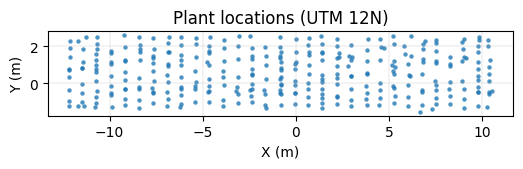

In [ ]:
# pip install pandas pyproj matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer

# 1) reas csv
csv_path = r"D:\zhan5455\SorghumProject\2021-07-29__09-18-39-727_sorghum\2021-07-29__09-18-39-727_sorghum_detect_out\detect_out\2021-07-29__09-18-39-727_sorghum_detection.csv"

csv_path = r"D:\zhan5455\SorghumProject\2021-08-02__13-11-38-442_sorghum\2021-08-02__13-11-38-442_sorghum_detect_out\detect_out\2021-08-02__13-11-38-442_sorghum_detection.csv"  

# csv_path = r"D:\zhan5455\SorghumProject\2021-07-27__11-30-47-477_sorghum_detect_out\detect_out\2021-07-27__11-30-47-477_sorghum_detection.csv"
df = pd.read_csv(csv_path)


# consider confidence
df = df[df["pred_conf"] >= 0.5]

print(len(df))
# 2) 
mean_lon = df["lon"].mean()
mean_lat = df["lat"].mean()
zone = int((mean_lon + 180) // 6) + 1
epsg = (32600 if mean_lat >= 0 else 32700) + zone   # 326xx north / 327xx south
print(f"Using UTM zone {zone}{'N' if mean_lat>=0 else 'S'} (EPSG:{epsg})")

tf = Transformer.from_crs(4326, epsg, always_xy=True)  # WGS84 -> UTM(米)

# 3) coordination translation
X, Y = tf.transform(df["lon"].values, df["lat"].values)

# 4) recenter
X0, Y0 = X.mean(), Y.mean()
df["X_m"] = X - X0
df["Y_m"] = Y - Y0
df["Z_m"] = 0.0 

plots = [7403,7404, 7407, 7408]

df_filtered = (df["plot"] >= 7401) & (df["plot"] < 7450)
X_draw = df[df_filtered]["X_m"]
Y_draw = df[df_filtered]["Y_m"]


for tag in ["nw", "se"]:
    x_corner, y_corner = tf.transform(df[f"{tag}_lon"].values, df[f"{tag}_lat"].values)
    df[f"{tag}_X_m"] = x_corner - X0
    df[f"{tag}_Y_m"] = y_corner - Y0

# 5) plot plants
fig, ax = plt.subplots(figsize=(6, 10))  
ax.scatter(X_draw, Y_draw, s=10, alpha=0.8, linewidths=0)   
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linewidth=0.2)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title(f"Plant locations (UTM {zone}N)")
# ax.set_ylim(-3, 3)
plt.show()

# 6) 
# c = df["plot"].values
# plt.scatter(df["X_m"], df["Y_m"], c=c, s=6, cmap="tab20", alpha=0.9); plt.colorbar()

# 7) export 3d positions
# points = np.column_stack([df["X_m"], df["Z_m"], df["Y_m"]])  # (x, y, z) = (X, Z, Y)
# np.savetxt("plant_points.xyz", points, fmt="%.3f", header="x y z (meters, local)")


In [ ]:
df_output = df[df_filtered]
pts = df_output[["X_m", "Y_m"]].to_numpy()        

out_path = r"D:\zhan5455\SorghumProject\points_xy.txt"
with open(out_path, "w", newline="\n") as f:
    f.write(f"{len(pts)}\n")              
    np.savetxt(f, pts, fmt="%.8f %.8f")